<center><font size = 8><b>COVID-19 Outcome Prediction</b></font></center><br\><br\>

### Name: Shadi mohamed alsaid abdelmeneam ameen 2000405
### Name: Mohamed fareed mohamed 2000933
<center><font size = 8><b>---------------------------------------------</b></font></center><br\><br\>


In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve as roc
from sklearn.metrics import auc 
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB

##The reading of the data

In [23]:
#  Read in the data
data = pd.read_csv("data.csv")
data_columns = data.iloc[:, 1:]
# 14 columns of data
data_columns.head()
data_columns.shape


(863, 14)

In [24]:
X=data_columns.iloc[:,0:13]
Y=data_columns['result']
# spilt the data for two parts 80% for train and 20% for test and validate (Holdout)
X_train, X_holdout, y_train, y_holdout  = train_test_split(X,Y, random_state=52 ,train_size=0.8,shuffle=True,stratify=Y)
X_validate, X_test, y_validate, y_test=  train_test_split(X_holdout,y_holdout , random_state=30 ,train_size=0.5,shuffle=True,stratify=y_holdout)
for data in [X_train, y_train,  X_test, y_test]:
    data.reset_index(drop=True, inplace=True)

# The training data : 80% of the data
print(X_train.shape, y_train.shape)

# The test data : 10% of the data
print(X_test.shape, y_test.shape)

(690, 13) (690,)
(87, 13) (87,)


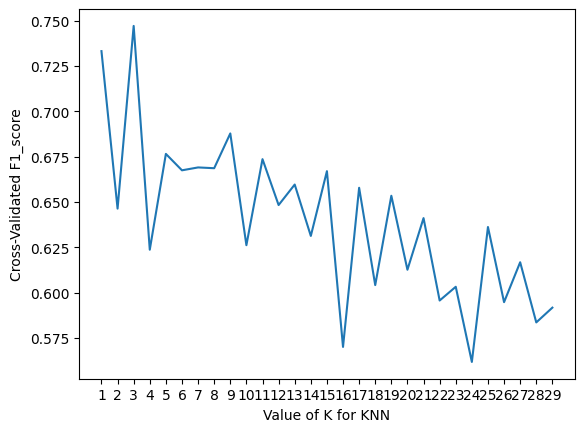

Best value for k: 3


In [20]:
#k cross validation to choose best value of K

F1_scores=[] #F1 scores array to choose the highest value
K_range=[k for k in np.arange(1,30) ]
for k in K_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train,y_train, cv=10, scoring='f1')
    F1_scores.append(scores.mean())
#plotting
plt.plot(K_range, F1_scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated F1_score')
plt.xticks(K_range)
plt.show()

best_k = K_range[np.argmax(F1_scores)]

# Print the Best k value that will be used in the KNN model
print("Best value for k:", best_k)

[[148   3]
 [  9  13]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96       151
           1       0.81      0.59      0.68        22

    accuracy                           0.93       173
   macro avg       0.88      0.79      0.82       173
weighted avg       0.93      0.93      0.93       173



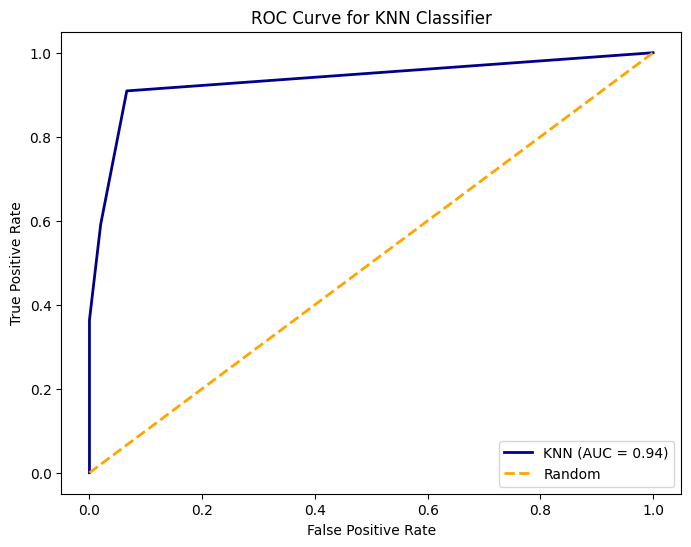

In [25]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train,y_train)
yknn_predict=knn.predict(X_holdout)

# Obtain predicted probabilities for the positive class
y_probs = knn.predict_proba(X_holdout)[:, 1]

# Compute the ROC curve
fpr_knn, tpr_knn, thresholds = roc(y_holdout, y_probs)

roc_auc_knn = auc(fpr_knn, tpr_knn)

print(metrics.confusion_matrix(y_holdout, yknn_predict))
print("Classification Report:\n", classification_report(y_holdout, yknn_predict))


#plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, color='darkblue', lw=2, label='KNN (AUC = {:.2f})'.format(roc_auc_knn))
plt.plot([0, 1], [0, 1], color="orange", lw=2, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for KNN Classifier')
plt.legend(loc='lower right')
plt.show()

In [26]:
#Tuning hyperparamters
LR = LogisticRegression()
LRparam_grid = {
    'C': [0.01, 0.1, 1, 10, 100, 1000],
    'penalty': ['none','l1', 'l2'],
    'solver': ['newton-cg', 'liblinear']
}
LR_search = GridSearchCV(LR, param_grid = LRparam_grid, scoring='f1', refit = True, verbose = 1, cv=12)

# fitting the model for the search to get the best parameters
LR_search.fit(X_train , y_train)
paramters= []
paramters = list(LR_search.best_params_.values())
lr = LogisticRegression(C= paramters[0] , penalty= paramters[1], solver= paramters[2])

Fitting 12 folds for each of 36 candidates, totalling 432 fits


c:\Users\RAMY\miniconda3\envs\py10\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
216 fits failed out of a total of 432.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
144 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\RAMY\miniconda3\envs\py10\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\RAMY\miniconda3\envs\py10\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "c:\Users\RAMY\miniconda3\envs\py10\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "

[[146   5]
 [  7  15]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96       151
           1       0.75      0.68      0.71        22

    accuracy                           0.93       173
   macro avg       0.85      0.82      0.84       173
weighted avg       0.93      0.93      0.93       173



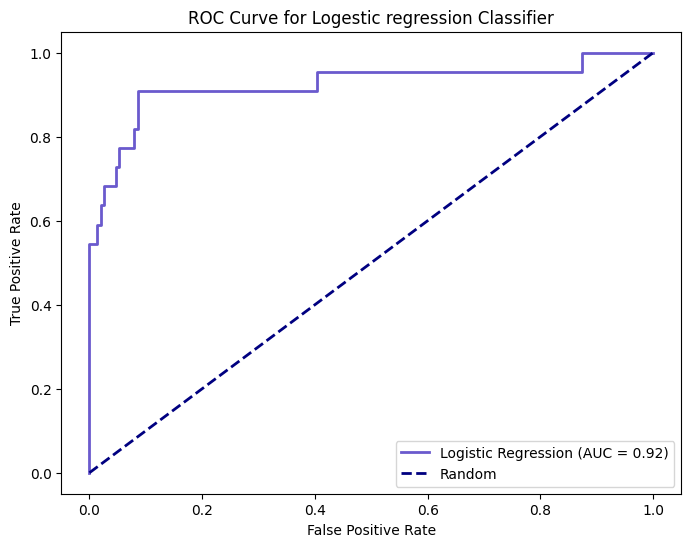

In [27]:
lr.fit(X_train, y_train)
ylr_predict = lr.predict(X_holdout)
print(metrics.confusion_matrix(y_holdout,ylr_predict ))

print("Classification Report:\n", classification_report(y_holdout, ylr_predict))
# Obtain predicted probabilities for the positive class
y_probs = lr.predict_proba(X_holdout)[:, 1]

# Compute the ROC curve
fpr_lr, tpr_lr, thresholds = roc(y_holdout, y_probs)

# Compute(AUC)
roc_auc_lr = auc(fpr_lr, tpr_lr)

#create ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='slateblue', lw=2, label='Logistic Regression (AUC = {:.2f})'.format(roc_auc_lr))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logestic regression Classifier')
plt.legend(loc='lower right')
plt.show()

[[ 46 105]
 [  2  20]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.30      0.46       151
           1       0.16      0.91      0.27        22

    accuracy                           0.38       173
   macro avg       0.56      0.61      0.37       173
weighted avg       0.86      0.38      0.44       173



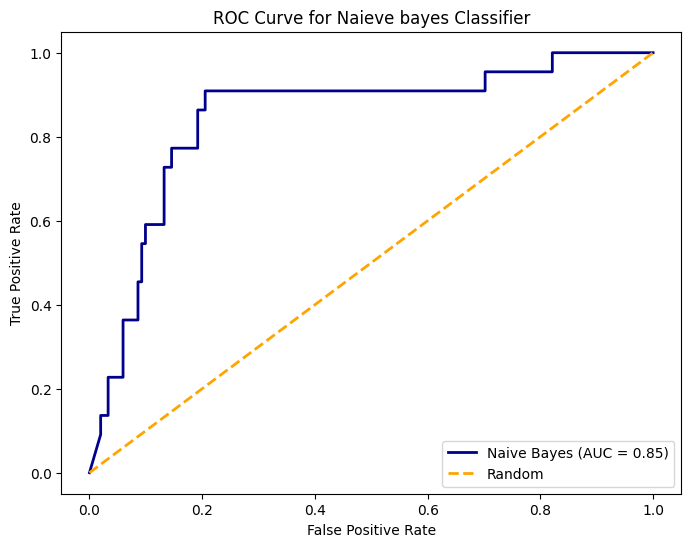

In [28]:
NB = GaussianNB()
NB.fit(X_train,y_train)
ynb_predict=NB.predict(X_holdout)

print(metrics.confusion_matrix(y_holdout, ynb_predict))

print("Classification Report:\n", classification_report(y_holdout, ynb_predict))
y_probs = NB.predict_proba(X_holdout)[:, 1]

# Compute the ROC curve
fpr_nb, tpr_nb, thresholds = roc(y_holdout, y_probs)

# Compute the Area Under the Curve (AUC)
roc_auc_nb = auc(fpr_nb, tpr_nb)

#create ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_nb, tpr_nb, color='darkblue', lw=2, label='Naive Bayes (AUC = {:.2f})'.format(roc_auc_nb))
plt.plot([0, 1], [0, 1], color='orange', lw=2, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Naieve bayes Classifier')
plt.legend(loc='lower right')
plt.show()

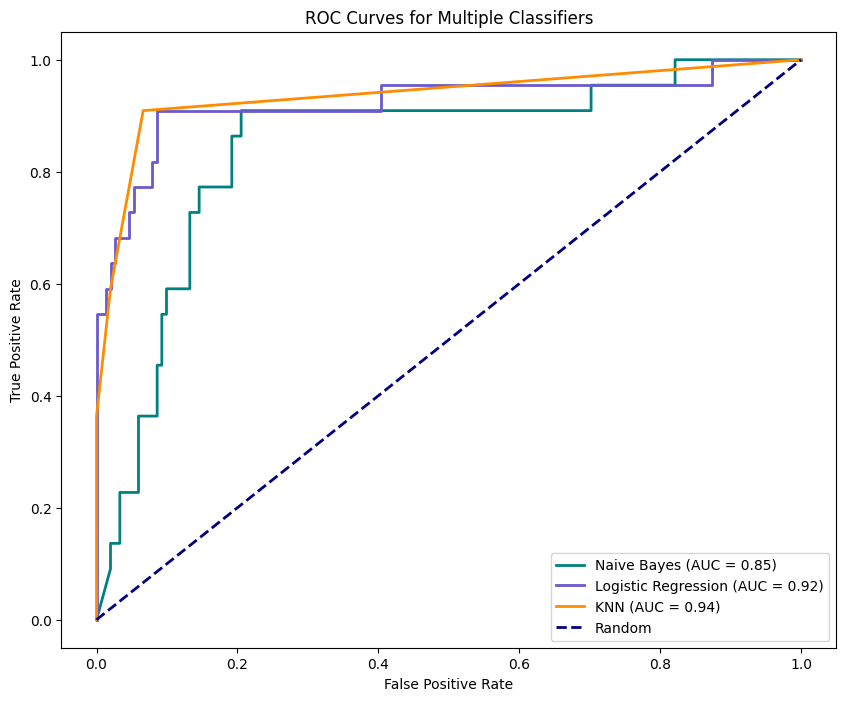

In [29]:
plt.figure(figsize=(10, 8))

# Naive Bayes ROC
plt.plot(fpr_nb, tpr_nb, color='teal', lw=2, label='Naive Bayes (AUC = {:.2f})'.format(roc_auc_nb))

# Logistic Regression ROC
plt.plot(fpr_lr, tpr_lr, color='slateblue', lw=2, label='Logistic Regression (AUC = {:.2f})'.format(roc_auc_lr))


plt.plot(fpr_knn, tpr_knn, color='darkorange', lw=2, label='KNN (AUC = {:.2f})'.format(roc_auc_knn))

# Random line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')

# Labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Multiple Classifiers')
plt.legend(loc='lower right')

plt.show()


# The best classifier is the one with the highest AUC value in this case it is the KNN classifier
